<a href="https://colab.research.google.com/github/aqilfiras/California-Housing-Prices-Prediction/blob/main/house_pricing_predictions.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [138]:
import pandas as pd
import numpy as np
import geopandas as gpd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import StandardScaler
from sklearn.base import clone
from sklearn.pipeline import Pipeline
from sklearn.linear_model import SGDRegressor
import numpy as np
from sklearn.impute import KNNImputer
import seaborn as sns

In [139]:
df = pd.read_csv('data/housing.csv')
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  str    
dtypes: float64(9), str(1)
memory usage: 1.6 MB


In [140]:
df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [141]:
train, test = train_test_split(df, test_size = 0.2, random_state=42)

In [142]:
def knn_impute(df: pd.DataFrame) -> pd.DataFrame:
    numeric_data = df.select_dtypes(include=np.number)
    categorical_data = df.select_dtypes(exclude=np.number)
    imputer = KNNImputer(n_neighbors=5)

    numeric_imputed = pd.DataFrame(
        imputer.fit_transform(numeric_data),
        columns=numeric_data.columns,
        index=df.index
    )
    df_imputed = pd.concat([numeric_imputed, categorical_data], axis=1)
    return df_imputed[df.columns]

train_imputed = knn_impute(train)
test_imputed = knn_impute(test)
train_imputed.info()

<class 'pandas.DataFrame'>
Index: 16512 entries, 14196 to 15795
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           16512 non-null  float64
 1   latitude            16512 non-null  float64
 2   housing_median_age  16512 non-null  float64
 3   total_rooms         16512 non-null  float64
 4   total_bedrooms      16512 non-null  float64
 5   population          16512 non-null  float64
 6   households          16512 non-null  float64
 7   median_income       16512 non-null  float64
 8   median_house_value  16512 non-null  float64
 9   ocean_proximity     16512 non-null  str    
dtypes: float64(9), str(1)
memory usage: 1.4 MB


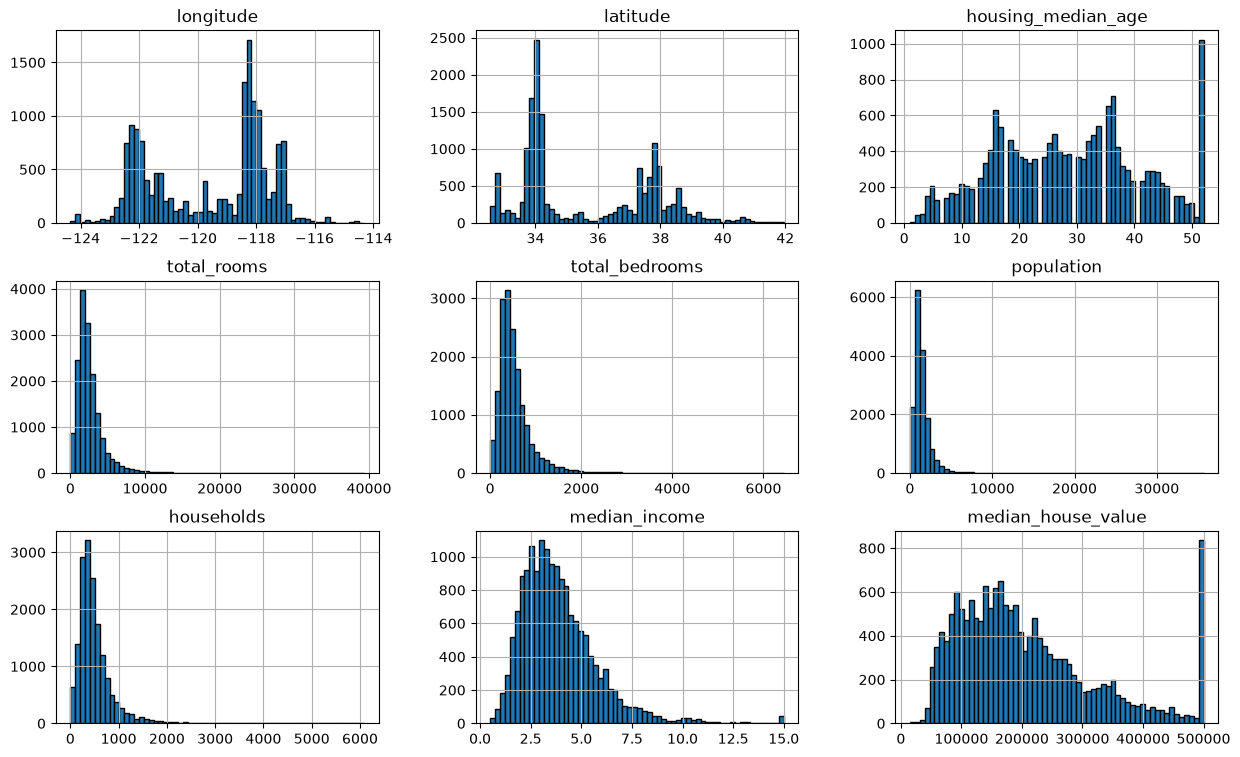

In [143]:
train_imputed.hist(bins = 60, edgecolor = 'black', figsize=(15,9))
plt.show()

In [144]:
train_imputed['median_house_value'].describe()

count     16512.000000
mean     207194.693738
std      115622.626448
min       14999.000000
25%      119800.000000
50%      179850.000000
75%      265125.000000
max      500001.000000
Name: median_house_value, dtype: float64

In [145]:
def feature_eng(df: pd.DataFrame) -> pd.DataFrame:
    res = df.copy()
    res['bedroom_per_rooms'] = res['total_bedrooms']/res['total_rooms']
    res['diag_coord'] = res['longitude'] + res['latitude']
    res['pop_per_house'] = res['population']/res['households']
    return res

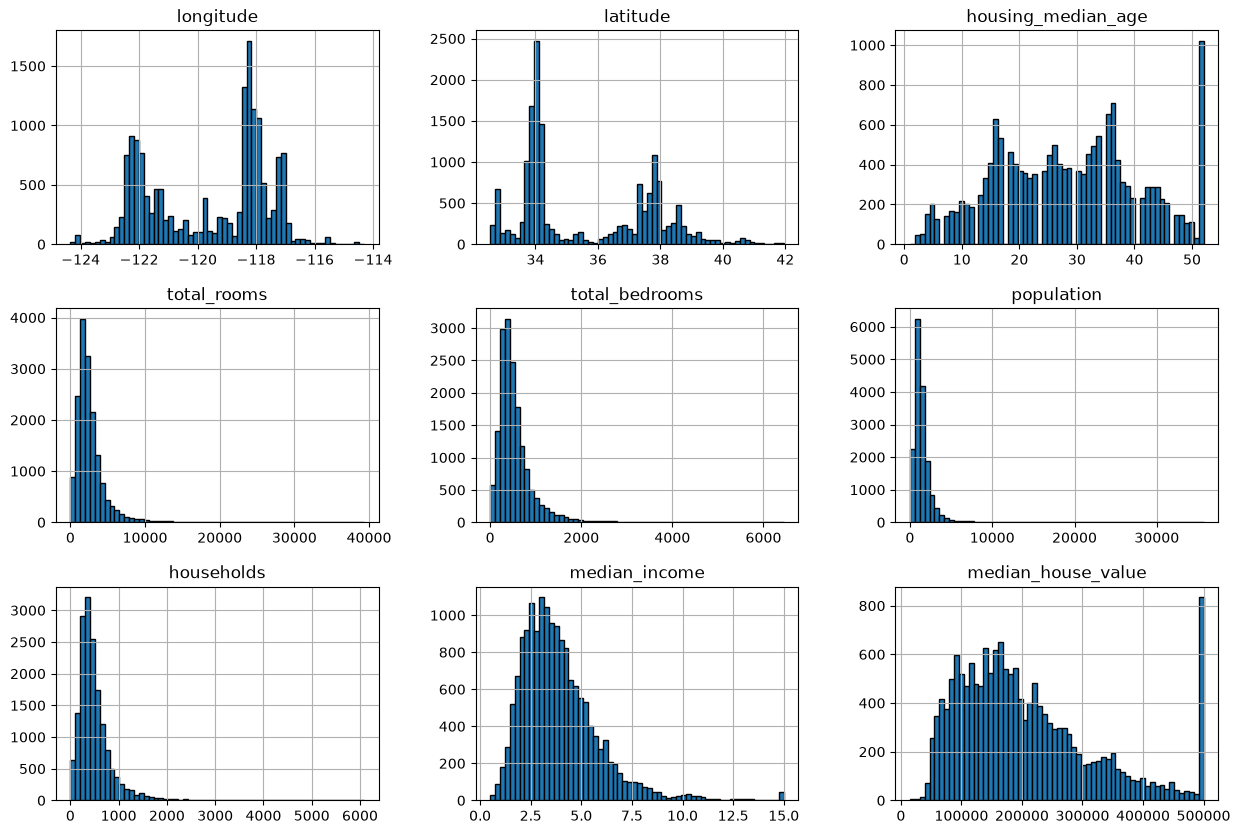

In [146]:
train_imputed.hist(bins = 60, edgecolor = 'black', figsize=(15,10))
plt.show()

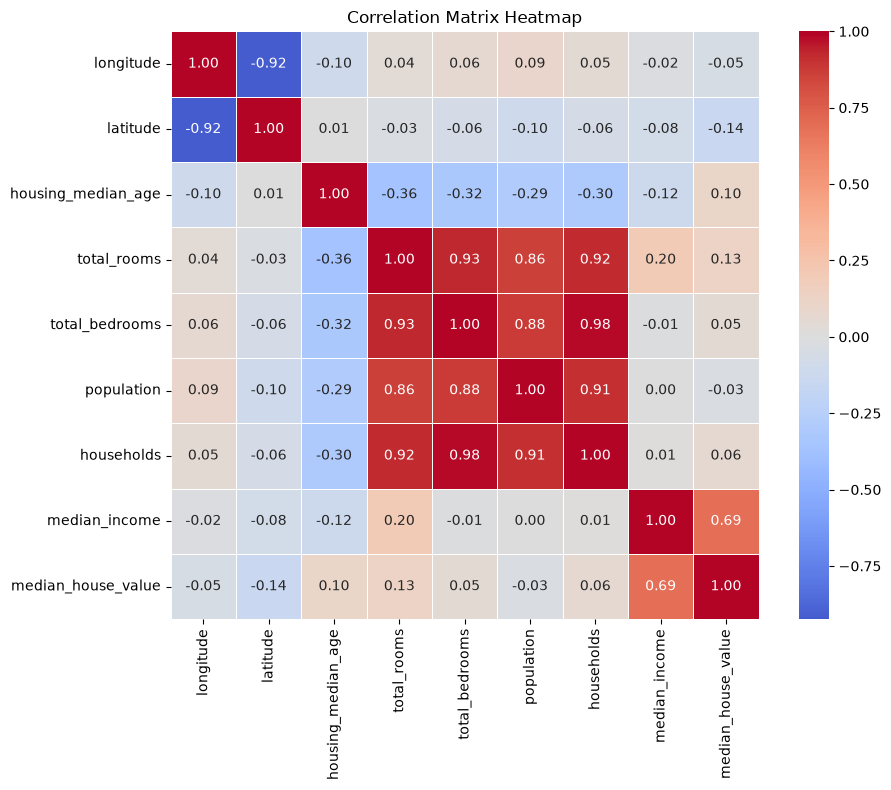

In [147]:
correlation_matrix = train_imputed.corr(numeric_only=True)

plt.figure(figsize=(10, 8))
sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    square=True,
    linewidths=0.5
)
plt.title('Correlation Matrix Heatmap')
plt.tight_layout()
plt.show()

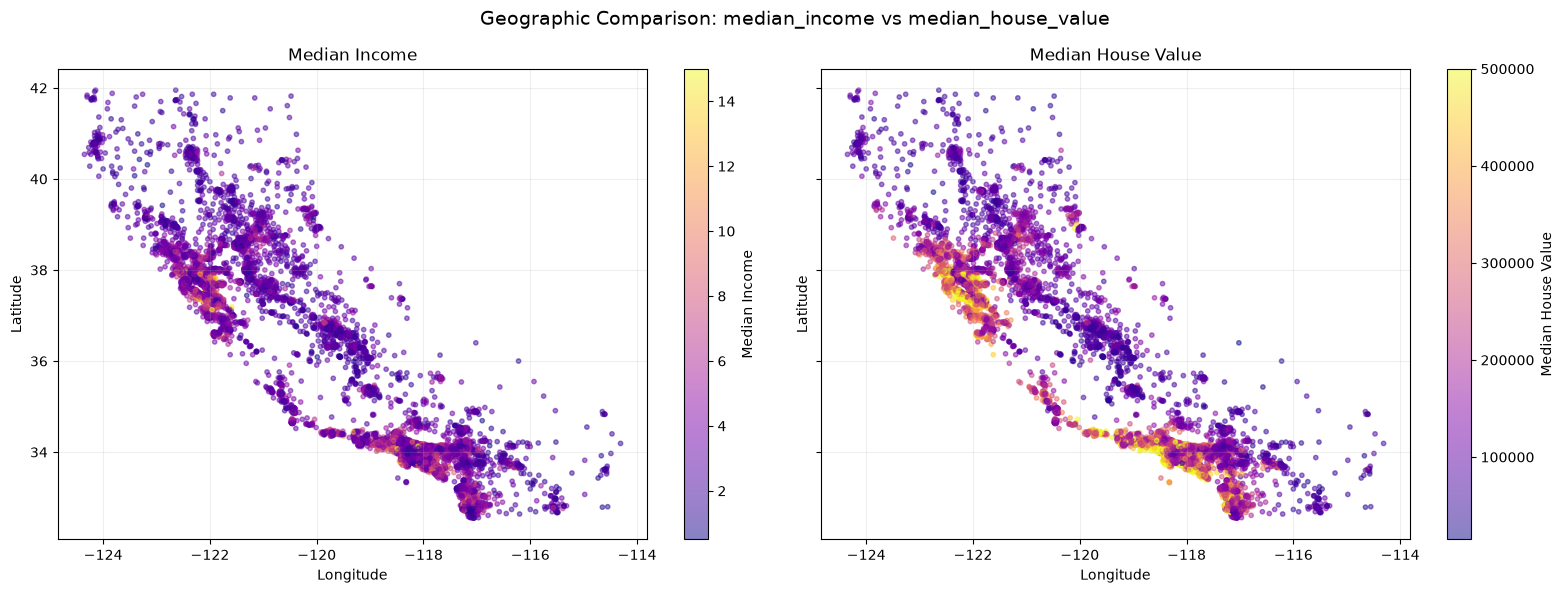

(<Figure size 1600x600 with 4 Axes>,
 array([<Axes: title={'center': 'Median Income'}, xlabel='Longitude', ylabel='Latitude'>,
        <Axes: title={'center': 'Median House Value'}, xlabel='Longitude', ylabel='Latitude'>],
       dtype=object))

In [148]:
def plot_geographic_features(
    df: pd.DataFrame,
    feature_1: str,
    feature_2: str,
    point_size: float = 10,
    alpha: float = 0.5,
    cmap: str = 'plasma'
):
    """Plot two numeric features geographically for side-by-side comparison."""
    required_columns = {'longitude', 'latitude', feature_1, feature_2}
    missing_columns = required_columns.difference(df.columns)
    if missing_columns:
        raise ValueError(f'Missing columns: {sorted(missing_columns)}')

    non_numeric_features = [
        feature for feature in (feature_1, feature_2)
        if not pd.api.types.is_numeric_dtype(df[feature])
    ]
    if non_numeric_features:
        raise TypeError(
            f'Features must be numeric: {non_numeric_features}'
        )

    fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharex=True, sharey=True)

    for axis, feature in zip(axes, (feature_1, feature_2)):
        plot_data = df[['longitude', 'latitude', feature]].dropna()
        scatter = axis.scatter(
            plot_data['longitude'],
            plot_data['latitude'],
            c=plot_data[feature],
            s=point_size,
            alpha=alpha,
            cmap=cmap
        )
        axis.set_title(feature.replace('_', ' ').title())
        axis.set_xlabel('Longitude')
        axis.set_ylabel('Latitude')
        axis.grid(alpha=0.2)
        fig.colorbar(scatter, ax=axis, label=feature.replace('_', ' ').title())

    fig.suptitle(f'Geographic Comparison: {feature_1} vs {feature_2}', fontsize=14)
    fig.tight_layout()
    plt.show()
    return fig, axes


plot_geographic_features(train_imputed,'median_income','median_house_value')

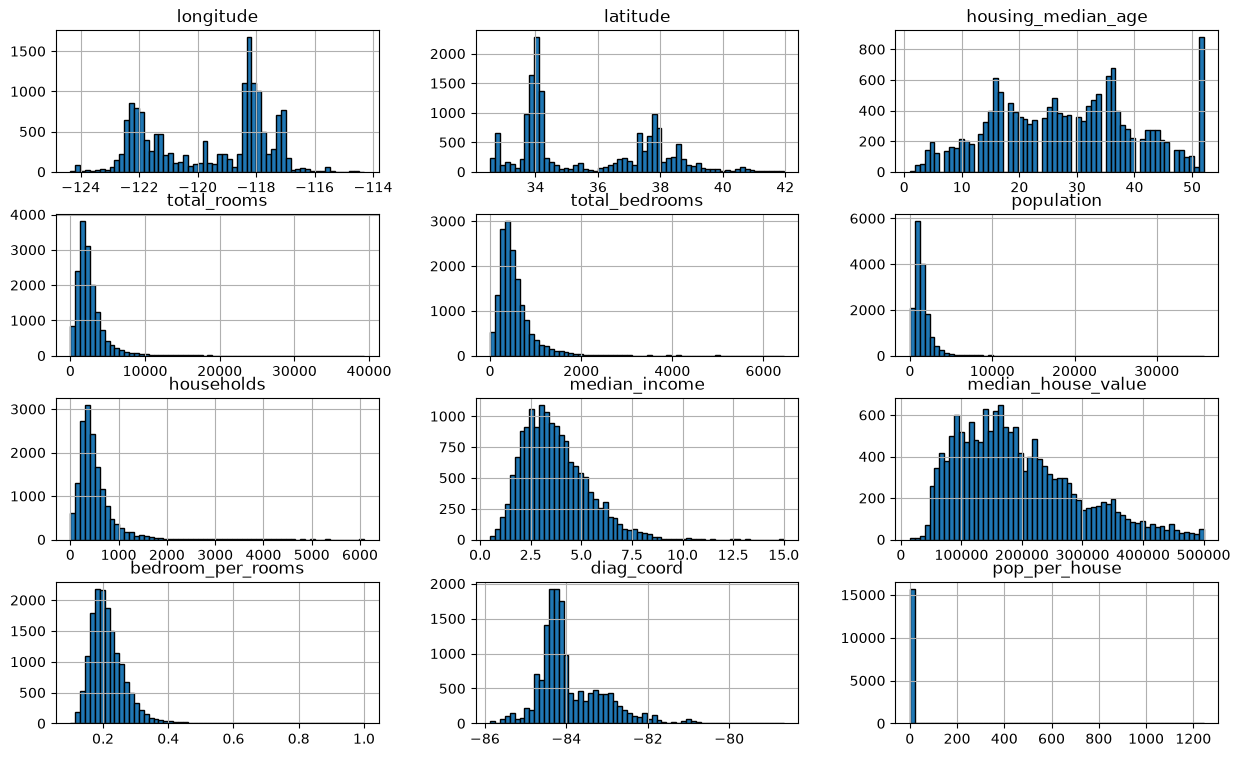

In [149]:
def remove_outliers(data: pd.DataFrame) -> pd.DataFrame:
    maxval = data['median_house_value'].max()
    return data[data['median_house_value']!=maxval]


train_update = remove_outliers(feature_eng(train_imputed))
test_update = remove_outliers(feature_eng(test_imputed))
train_update.hist(bins = 60, figsize=(15,9), edgecolor = 'black')
plt.show()

In [150]:
train_update.corr(numeric_only=True)['median_house_value'].sort_values(ascending=False)

median_house_value    1.000000
median_income         0.642407
total_rooms           0.144983
households            0.096007
total_bedrooms        0.076054
housing_median_age    0.061479
population            0.012789
pop_per_house        -0.019776
longitude            -0.044505
latitude             -0.149412
bedroom_per_rooms    -0.217462
diag_coord           -0.498934
Name: median_house_value, dtype: float64

In [151]:
train_update = pd.get_dummies(train_update, columns=['ocean_proximity'])
train_imputed = pd.get_dummies(train_imputed, columns=['ocean_proximity'])
test_update = pd.get_dummies(test_update, columns=['ocean_proximity'])
test_imputed = pd.get_dummies(test_imputed, columns=['ocean_proximity'])

In [152]:
def modelEval(ldf,feature='median_house_value',model_id = 'rf'):
    
    # Input: Feature & Target DataFrame

    # Split feature/target variable
    y = ldf[feature].copy()
    X = ldf.copy()
    del X[feature]     # remove target variable
    
    # Pick Model 
    if(model_id == 'rf'):    model = RandomForestRegressor(n_estimators=10,random_state=10)
    cv_score = np.sqrt(-cross_val_score(model,X,y,cv=5,scoring='neg_mean_squared_error'))
    print("Scores:",cv_score)
    print("Mean:", cv_score.mean());print("std:", cv_score.std())

modelEval(train_imputed)
modelEval(train_update)

Scores: [51719.49495184 51795.9483642  51114.8111445  50809.32950265
 52960.44430385]
Mean: 51680.005653407876
std: 739.195109134562
Scores: [46611.22331172 47234.78364611 46154.59083267 47438.03830661
 47887.80565864]
Mean: 47065.288351150615
std: 613.1477694050709


In [153]:
train_update2 = train_update.drop(columns = ['households', 'total_bedrooms', 'pop_per_house', 'population', 'housing_median_age'])
modelEval(train_update2)

Scores: [47196.56133945 45704.62865449 45978.22440539 46671.98345747
 48174.56453282]
Mean: 46745.19247792581
std: 885.8003133946182


In [155]:
train_update3 = train_update.drop(columns = ['households', 'total_bedrooms', 'pop_per_house', 'population'])
max_val_age = train_update['housing_median_age'].max()
train_update3 = train_update3[train_update3['housing_median_age'] !=max_val_age]
modelEval(train_update3)

Scores: [46627.10824792 45222.82740688 45273.28324924 46186.42571482
 47059.12022162]
Mean: 46073.75296809502
std: 728.6524438210869


In [ ]:
def modelEval(ldf,feature='median_house_value',model_id = 'rf'):
    
    # Input: Feature & Target DataFrame

    # Split feature/target variable
    y = ldf[feature].copy()
    X = ldf.copy()
    del X[feature]     # remove target variable
    
    # Pick Model 
    if(model_id == 'rf'):    model = RandomForestRegressor(n_estimators=10,random_state=10)
    cv_score = np.sqrt(-cross_val_score(model,X,y,cv=5,scoring='neg_mean_squared_error'))
    print("Scores:",cv_score)
    print("Mean:", cv_score.mean());print("std:", cv_score.std())